In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 데이터 생성: 점수 40~99, 60 초과면 합격(1)
np.random.seed(42)
exam_scores = np.random.randint(40, 100, 100)
y = (exam_scores > 60).astype(int)
X = exam_scores.reshape(-1, 1)        # 2차원 형태로 변환

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"정확도: {accuracy_score(y_test, y_pred):.2f}")

정확도: 1.00


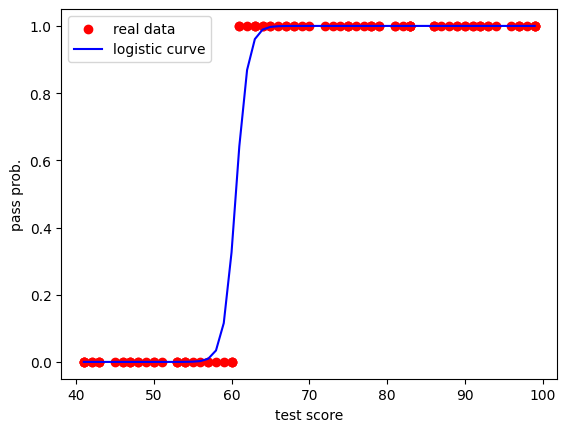

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X, y, color="red", label="real data")
# predict_proba[:,1] = 합격(1)일 확률
plt.plot(np.sort(X, axis=0),
         model.predict_proba(np.sort(X, axis=0))[:, 1],
         color="blue", label="logistic curve")
plt.xlabel("test score"); plt.ylabel("pass prob."); plt.legend(); plt.show()

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score)

b = load_breast_cancer()
X = StandardScaler().fit_transform(b.data)   # 정규화
y = b.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("오차행렬:\n", confusion_matrix(y_test, y_pred))
print(f"정확도 {accuracy_score(y_test, y_pred):.3f}, 정밀도 {precision_score(y_test, y_pred):.3f}")
print(f"재현율 {recall_score(y_test, y_pred):.3f}, F1 {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC {roc_auc_score(y_test, y_pred):.3f}")

오차행렬:
 [[ 60   3]
 [  1 107]]
정확도 0.977, 정밀도 0.973
재현율 0.991, F1 0.982
ROC-AUC 0.972


In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

params = {"max_depth": [4, 8, 12, 16]}     # 나무 깊이 후보
grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    param_grid=params, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)
print("최적 파라미터:", grid.best_params_)
print(f"최고 평균 정확도: {grid.best_score_:.4f}")
best = grid.best_estimator_     # 최적 모델로 다시 예측 가능

최적 파라미터: {'max_depth': 8}
최고 평균 정확도: 0.9221
